In [71]:
# Importing necessary libraries
import pandas as pd  # For data manipulation and handling CSV files
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt
# Importing libraries from TensorFlow for neural network construction
from tensorflow.keras.models import Sequential  # Allows us to create a linear stack of layers
from tensorflow.keras.layers import Dense  # For adding fully connected layers
from tensorflow.keras.utils import to_categorical  # To convert labels to one-hot encoding format

In [41]:
# Load the MNIST dataset from the provided 'mnist.csv' file using pandas
# Assuming 'mnist.csv' has the label in the first column and pixel values in the rest
data = pd.read_csv('./Datasets/MNIST/mnist.csv')

# Display the first few rows of the dataset to understand its structure
data.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [46]:
# Separate the features (pixel values) and labels (digits)
#X = data.iloc[:, 1:].values  # Select all rows and all columns except the first (contains pixel values)
#y = data.iloc[:, 0].values  # Select all rows of the first column (contains labels)
# ----------
# Set the independent variable `X` as all columns except the last 'class' column
X = data.iloc[:, :-1].values  # Selects all rows and all columns except the last

# Set the dependent variable `y` as the 'class' column (target variable)
Y = data['class'].values  # Selects all rows of the 'class' column only
# --------------

# Normalize the pixel values to a range between 0 and 1
# This helps the model to learn faster and achieve better accuracy
X = X / 255.0

# Convert labels to one-hot encoding format for multiclass classification
Y = to_categorical(Y, num_classes=10)

In [47]:
# Initialize a Sequential model, which allows adding layers in sequence
model = Sequential()

# Add the input layer with 128 neurons and 'relu' activation function
# Input shape is 784 because each image is 28x28 pixels, flattened into a vector
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Add a hidden layer with 64 neurons and 'relu' activation function
model.add(Dense(64, activation='relu'))

# Add an output layer with 10 neurons (one for each digit 0-9) and 'softmax' activation
# Softmax is used to output probabilities for multiclass classification
model.add(Dense(10, activation='softmax'))

In [49]:
# Compile the model to configure it for training
# Using 'adam' optimizer for efficient gradient descent
# 'categorical_crossentropy' is used as the loss function for multiclass classification
# We will evaluate the model using 'accuracy' metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
# Train the model using the training data (X and y)
# Setting epochs (number of passes through the data) and batch_size (samples per gradient update)
# Validation_split = 0.2 reserves 20% of the data for validation
history = model.fit(X, Y, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8733 - loss: 0.4349 - val_accuracy: 0.9649 - val_loss: 0.1216
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9661 - loss: 0.1113 - val_accuracy: 0.9726 - val_loss: 0.0928
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0759 - val_accuracy: 0.9766 - val_loss: 0.0782
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9821 - loss: 0.0532 - val_accuracy: 0.9781 - val_loss: 0.0762
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9862 - loss: 0.0424 - val_accuracy: 0.9744 - val_loss: 0.0889
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9773 - val_loss: 0.0815
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.9793 - val_loss: 0.0778
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9918 - loss: 0.0236 - 

In [51]:
data.columns

Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10',
       ...
       'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780', 'pixel781',
       'pixel782', 'pixel783', 'pixel784', 'class'],
      dtype='object', length=785)

In [52]:
# Evaluate the model on the training data to see final accuracy
# Returns the loss and accuracy
loss, accuracy = model.evaluate(X, Y)

# Print the final accuracy achieved on the dataset
print(f"Model Accuracy: {accuracy * 100:.2f}%")

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9945 - loss: 0.0171
Model Accuracy: 99.17%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
The predicted digit is: 5


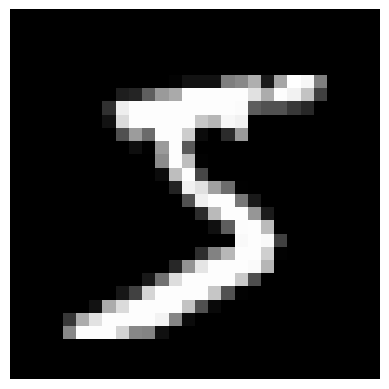

In [105]:
import numpy as np  # Import numpy for array operations if not already imported

# Perform the prediction for the first sample
prediction = model.predict(data.iloc[[0], :-1])

# Find the index of the highest probability, which is the predicted class
predicted_digit = np.argmax(prediction)

# Display the predicted digit
print(f"The predicted digit is: {predicted_digit}")
image = data.iloc[0, :-1].values.reshape(28,28)
plt.axis('off')
plt.imshow(image, cmap='gray')
plt.show()  # Show the image

In [109]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

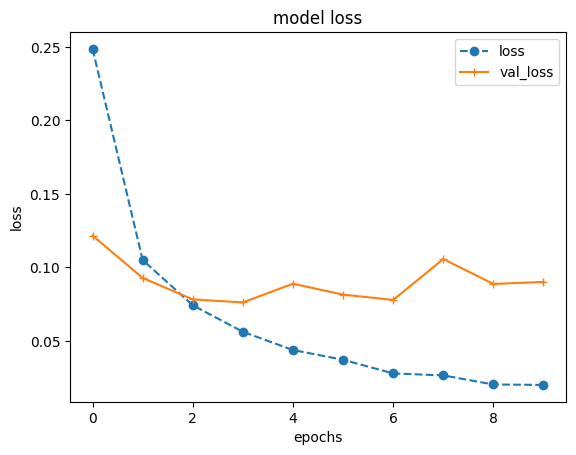

In [124]:
plt.title('model loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(history.history['loss'], label='loss', linestyle='--', marker='o')
plt.plot(history.history['val_loss'], label='val_loss', linestyle='-', marker='+')
plt.legend()
plt.show()
# plt.axis('off')

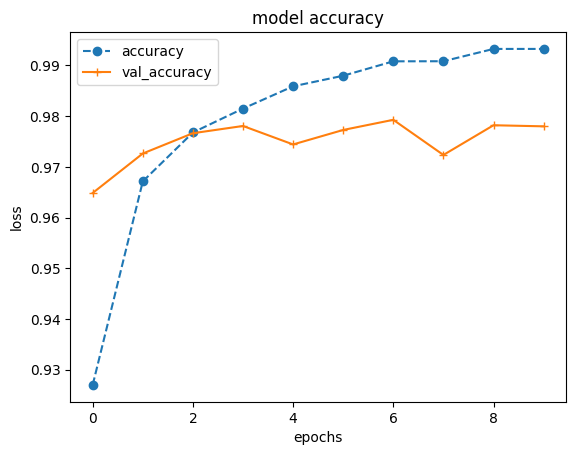

In [126]:
plt.title('model accuracy')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(history.history['accuracy'], label='accuracy', linestyle='--', marker='o')
plt.plot(history.history['val_accuracy'], label='val_accuracy', linestyle='-', marker='+')
plt.legend()
plt.show()

In [54]:
data['class'].value_counts()

class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64

### npi

In [103]:
from keras.utils import to_categorical

# Example labels (only 10 classes)
y_labels = [i for i in range(0,10)]

# Convert labels to one-hot encoding without specifying num_classes
y_one_hot = to_categorical(y_labels)

# Print the one-hot encoded labels
print(y_one_hot)
type(y_one_hot)
y_one_hot[0,0]

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


1.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Digit predicted : 3


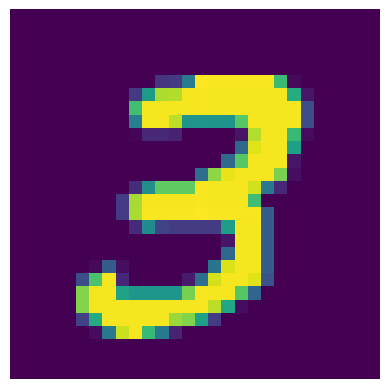

In [149]:
prediction = model.predict(data.iloc[7:8,:-1])
prediction = np.argmax(prediction)
print(f"Digit predicted : {prediction}")

image = data.iloc[7:8,:-1].values.reshape(28,28)
plt.axis('off')
plt.imshow(image)
plt.show()